In [14]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network

## Loading the Data

In [15]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [16]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [17]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

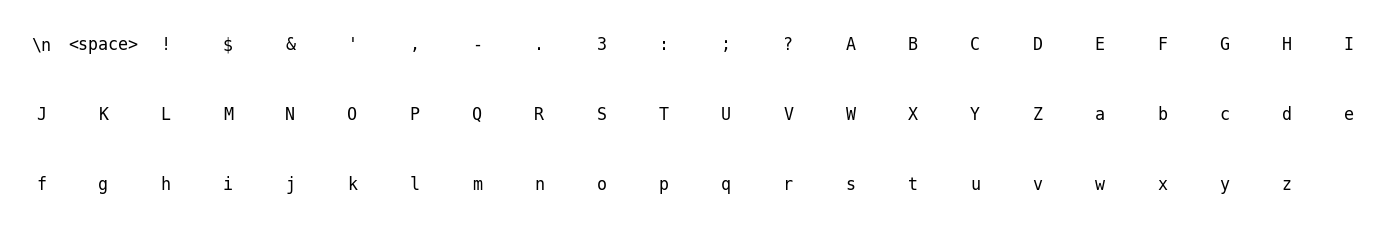

In [18]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [20]:
embedding_dim = 64
hidden_size = 256
hidden_2_size = 128

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Recurrent", "input_size": hidden_size, "num_neurons": hidden_2_size},
    {"type": "Softmax", "input_size": hidden_2_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 64)
  Parameters: 4,160

Layer 2: RecurrentLayer
  Weights Shape: (64, 256) | State Weights Shape: (256, 256) | Biases Shape: (256,)
  Parameters: 82,176

Layer 3: RecurrentLayer
  Weights Shape: (256, 128) | State Weights Shape: (128, 128) | Biases Shape: (128,)
  Parameters: 49,280

Layer 4: SoftmaxLayer
  Weights Shape: (128, 65) | Biases Shape: (65,)
  Parameters: 8,385

Total Parameters: 144,001


## Training the Model

In [21]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [22]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [23]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [24]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [25]:
sequence_length = 64
batch_size = 64
epochs = 500
train_steps_per_epoch = 3072
validation_steps = 1024
base_learning_rate = 0.05
min_learning_rate = 0.0005
weight_decay_lambda = 1e-4
momentum = 0.9
early_stopping_patience = 15

In [26]:
epoch_summaries = []

total_steps = epochs * train_steps_per_epoch
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        learning_rate=learning_rate,
        max_steps=train_steps_per_epoch,
        weight_decay_lambda=weight_decay_lambda,
        momentum=momentum,
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        max_steps=validation_steps,
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if epoch % 50 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break

{'epoch': 1, 'learning_rate': 0.05, 'train_perplexity': 15.016886958899827, 'test_perplexity': 10.054158865438323}
{'epoch': 50, 'learning_rate': 0.048836238702551174, 'train_perplexity': 4.330199793820508, 'test_perplexity': 5.0760757633656075}
Early stopping triggered after 77 epochs due to no improvement.


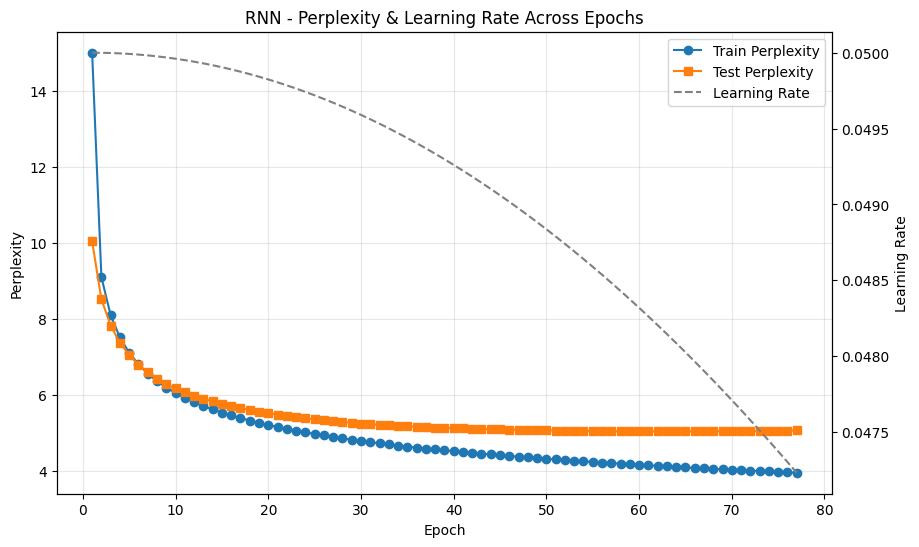

In [27]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
learning_rates = [summary["learning_rate"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, learning_rates, color="gray", linestyle="--", linewidth=1.5, label="Learning Rate")
ax2.set_ylabel("Learning Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("RNN - Perplexity & Learning Rate Across Epochs")
plt.show()

In [28]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [29]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.9, print_during=True)

DANIELAND:
The speaker bear be inselves away?
And you close for your city.

ISABELLA:
Let it thou than with our restle.

GREGBEY:
No stand in your foot, and Northam this is the ingried foot when this sacred become to be an eap me been the be would bid thee come, so my sweet my manoch but time;
Manance one,
To all me; beathing and med of leadably the friends.
Had joy of Edward's a serving which sir! 'efied;
But all too, I should noe them to heath, what he
not plessain:
The king, where you appear to you appeaching hence, for many seem to march with meet on what main?

KING RICHARENCE:

HENRY VALIV:
Crevenge, the noble longs of you can that all, and sick! O tell the trade Waves.
I would thee, my break his pleal back foring mounted when he not fool answied to Ramiliciing years you fly;
That Mantury mine pointward to boots and power 'em; ere not see that tell meel me shall be who de.

ROMEO:
Stay tit the ground your fair and steed?

ESCALUS:
He'l,
And the me, look you, lost, to have I dear 

In [30]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIELAUCHESS OF YORK:
If the bed his woild change the be, thou lie, the maidenen, my lord, how thou thou wilt.

Nurse:
Theselves.

BIONE:
Not of your intert
As the bed move much the more this news, as this strewas must prove such and the revenged with heardol home, what come to our consent on Aunisous from my now, his hurts and prince thee to your kind
Our receive the heart me, you are now the hereing to be the king shows and friends:
What thousand marriage upon the king, and thy son, O, the maid of him to be condemned man all with my lord, blows in a tunnatal be the head!

MENENIUS:
I thank thee word it, man be stand
the army,
That's the trice and lends
The boy.

STANLEY:
There you who before! you will not so contend to the table of blood
That we what should see maid of you not the sent to was words. Thou have companing for the counsel grace come, for the voitable, white this is the Lord Edward.

DUKE VINCENTIO:
I hourseting would have this one of this this see this devise: she along

In [31]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.5, print_during=True)

DANIELAUMIO:
Nay, for the ship the seated these his seem the pain, they leave his prove with the very oft thee with from the field this cannot end that I must be the news a death, as death.

KING RICHARD III:
Stay the men, thou should make you think of the house of yourselves
And yet with the heart in strange of Glouces and pleased, but shall not so a good more poor brother shall hear all the free in the soft stand the cannot content.

CORIOLANUS:
Nay, not sweet may thou shall see this country the prove the crowndness and heavens of leave up the sun the faint by the head;
And the grace me, in the seated against be not prove him good lord, what thou art the truth of the earth and the would needer may made to be watch in the seek of the seal him,
Who hear now the change the brother for the sees the heart and heart him to the world of his for the heart my treason of all the holy considered to the was my too it, more would may be the hours of this stir
This we singen as this is the very so

In [32]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.3, print_during=True)

DANIELAUMENCE:
In the surrent and most thou hast shall have any heart and the sent and the replied and shall see the head, and the stop of the world and the parties to the crown,
To me, I would have bear the heads to the world, the very should not the wear the wear to the bear the world, what thou wilt not the stand the worst should not she is the better the bear the worst me, for the constance you have strike a soldiers and meet and grief alast you that I shall the truth of this pains the heart of the hours of the villains, the tell me that he shall deeds and resolve the head,
That be a gentleman and the was the faint thou hast should stand the bear me the call the sent the fearful change the beggar may should not the sun the see that I say and the may see him to hear of the hours and the shall death, and the world the head of the crown,
That fair faint the faint thou hast stand of the worthy sole the send the sent and enemy and the thine eyes and should say the parting to the world a